## ADASYN ДЛЯ КУРСОВОЙ

Загрузим наш набор данных

In [3]:
import pandas as pd

data = pd.read_csv('diabetes_prediction_dataset.csv')

data['gender'] = data['gender'].map({'Male': 1, 'Female': 0})

smoking_map = {
    'never': 0,
    'No Info': 1,
    'current': 2,
    'former': 3,
    'ever': 4,
    'not current': 5
}
data['smoking_history'] = data['smoking_history'].map(smoking_map)

print(data.head())

""" target = 'diabetes'
features = data.columns.drop(target) """

   gender   age  hypertension  heart_disease  smoking_history    bmi  \
0     0.0  80.0             0              1                0  25.19   
1     0.0  54.0             0              0                1  27.32   
2     1.0  28.0             0              0                0  27.32   
3     0.0  36.0             0              0                2  23.45   
4     1.0  76.0             1              1                2  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


" target = 'diabetes'\nfeatures = data.columns.drop(target) "

Text(0.5, 1.0, 'Scatter Plot for HbA1c_level VS blood_glucose_level')

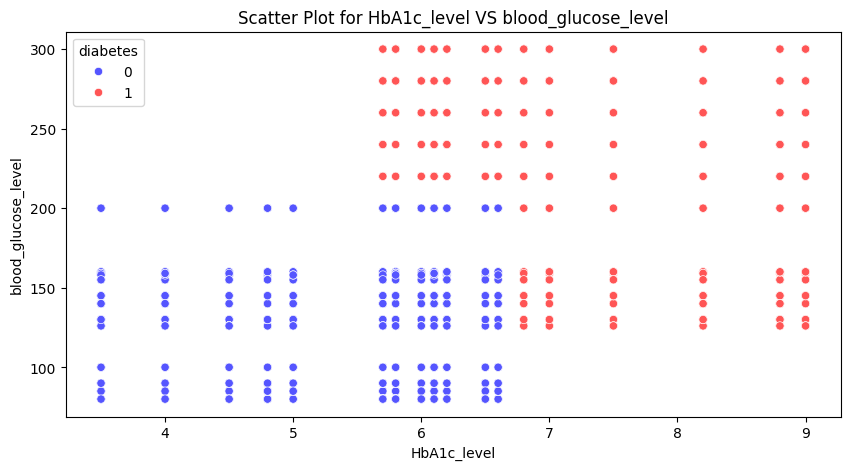

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize = (10, 5)) #фигура + координатная плоскость
#Строим диаграмму рассеяния
sns.scatterplot(
    data=data, #датасет
    x='HbA1c_level', #ось абсцисс
    y='blood_glucose_level', #ось ординат
    hue='diabetes', #группировка
    palette='seismic', #палитра
    ax=ax, #координатная плоскость
);
#Задаём название графика
ax.set_title('Scatter Plot for HbA1c_level VS blood_glucose_level')

Проведу небольшое исследование. Видно на графике, что в диапазоне от 6 до 6.1 по HbA1c_level и от 150 до 160 по blood_glucose_level находятся только класс 0 (не диабет). Так ли это? Сделаем фильтрацию датасета по этому квадрату и посмотрим сколько объектов какому классу принадлежит.

In [5]:
filtered_data = data[
    (data['HbA1c_level'] >= 6.0) & (data['HbA1c_level'] <= 6.1) &  # Диапазон для HbA1c_level
    (data['blood_glucose_level'] >= 150) & (data['blood_glucose_level'] <= 160)  # Диапазон для blood_glucose_level
]

print("Данные в заданном диапазоне:")
print(filtered_data)

Данные в заданном диапазоне:
       gender   age  hypertension  heart_disease  smoking_history    bmi  \
29        1.0  43.0             0              0                0  26.08   
50        1.0  57.0             0              0                0  27.32   
63        0.0  59.0             0              0                3  27.32   
100       1.0  38.0             0              0                0  27.32   
103       0.0  55.0             0              0                4  18.60   
...       ...   ...           ...            ...              ...    ...   
99769     1.0  14.0             0              0                0  21.00   
99832     1.0  52.0             0              0                0  30.53   
99858     1.0  44.0             0              0                1  24.36   
99872     0.0  37.0             0              0                5  25.69   
99884     1.0  16.0             0              0                1  19.31   

       HbA1c_level  blood_glucose_level  diabetes  
29    

In [6]:
# Подсчет строк для каждого класса
class_counts = filtered_data['diabetes'].value_counts()

print("Количество строк в каждом классе:")
print(class_counts)

Количество строк в каждом классе:
diabetes
0    4624
1     285
Name: count, dtype: int64


Видно, что хоть и класс 0 преобладает, но и класс 1 также имеет несколько объектов в этом квадрате.

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               99982 non-null   float64
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  int64  
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 6.9 MB


In [5]:
data[data['gender'].isna()]

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
12669,NaN,10.0,0,0,5,14.09,5.0,140,0
14838,NaN,19.0,0,0,1,27.32,5.7,158,0
16702,NaN,39.0,0,0,5,31.24,6.2,85,0
18691,NaN,10.0,0,0,5,16.59,6.1,160,0
23266,NaN,23.0,0,0,1,24.23,6.1,140,0
31985,NaN,53.0,0,0,1,27.32,6.6,160,0
33805,NaN,45.0,0,0,0,27.32,4.0,159,0
34929,NaN,47.0,0,0,0,36.76,6.6,90,0
35006,NaN,47.0,0,0,0,36.76,3.5,200,0
40337,NaN,18.0,0,0,5,30.19,6.1,90,0


Безболезненно можем удалить

In [6]:
data = data.dropna()

In [17]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from imblearn.over_sampling import ADASYN
from sklearn.model_selection import train_test_split

# Разделяем данные на признаки и целевой класс
X = data.drop('diabetes', axis=1)  # Замените 'diabetes' на название целевого столбца
y = data['diabetes']

# Разделяем данные по классам
X_class0 = X[y == 0]  # Данные для класса 0
X_class1 = X[y == 1]  # Данные для класса 1

# 1. Удаление выбросов в классе 0
iso_forest_0 = IsolationForest(random_state=42, contamination=0.05)  # 5% выбросов
outliers_0 = iso_forest_0.fit_predict(X_class0)
X_class0_cleaned = X_class0[outliers_0 == 1]  # Убираем выбросы

# 2. Удаление выбросов в классе 1
iso_forest_1 = IsolationForest(random_state=42, contamination=0.05)  # 5% выбросов
outliers_1 = iso_forest_1.fit_predict(X_class1)
X_class1_cleaned = X_class1[outliers_1 == 1]  # Убираем выбросы

# 3. Урезаем класс 0 до 40,000 объектов
if len(X_class0_cleaned) > 40000:
    X_class0_cleaned, _ = train_test_split(X_class0_cleaned, train_size=40000, random_state=42)

# 4. Объединяем очищенные данные класса 0 и класс 1
X_combined = pd.concat([X_class0_cleaned, X_class1_cleaned])
y_combined = np.concatenate([
    [0] * len(X_class0_cleaned),  # Метки для класса 0
    [1] * len(X_class1_cleaned)  # Метки для класса 1
])

# 5. Применяем ADASYN для избавления от дисбаланса
adasyn = ADASYN(sampling_strategy=0.95, random_state=42, n_neighbors=5)  # Сбалансировать классы
X_balanced, y_balanced = adasyn.fit_resample(X_combined, y_combined)

# 6. Проверяем итоговые размеры классов
print("Распределение классов после обработки:")
print(pd.Series(y_balanced).value_counts())

# Финальный результат
balanced_df = pd.concat([pd.DataFrame(X_balanced, columns=X.columns), pd.Series(y_balanced, name='diabetes')], axis=1)

# Просмотр сбалансированных данных
print(balanced_df.head())


Распределение классов после обработки:
0    40000
1    37314
Name: count, dtype: int64
   gender   age  hypertension  heart_disease  smoking_history    bmi  \
0     1.0  36.0             0              0                1  22.46   
1     0.0  77.0             0              0                3  27.32   
2     0.0   1.4             0              0                1  13.47   
3     1.0  26.0             0              0                0  27.32   
4     0.0  71.0             0              0                5  32.44   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.5                  155         0  
1          5.8                  155         0  
2          6.0                  140         0  
3          6.6                  200         0  
4          6.6                  159         0  


In [11]:
balanced_df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,1.000000,36.000000,0,0,1,22.460000,6.500000,155,0
1,0.000000,77.000000,0,0,3,27.320000,5.800000,155,0
2,0.000000,1.400000,0,0,1,13.470000,6.000000,140,0
3,1.000000,26.000000,0,0,0,27.320000,6.600000,200,0
4,0.000000,71.000000,0,0,5,32.440000,6.600000,159,0
...,...,...,...,...,...,...,...,...,...
77316,0.279924,65.000000,1,0,0,34.129444,8.200000,140,1
77317,0.000000,58.602016,1,0,0,38.966198,6.397984,200,1
77318,0.034674,57.965326,0,0,0,38.251402,6.972261,200,1
77319,0.000000,58.000000,1,0,0,38.411797,6.915169,200,1


Text(0.5, 1.0, 'Scatter Plot for HbA1c_level VS blood_glucose_level')

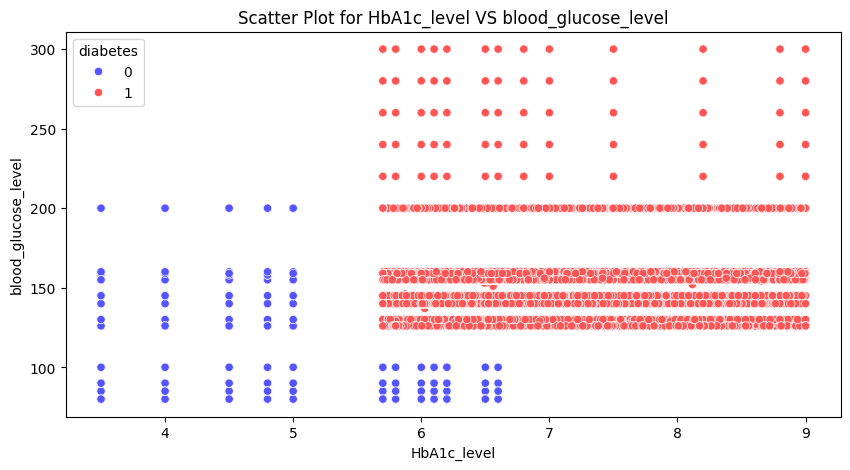

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize = (10, 5)) #фигура + координатная плоскость
#Строим диаграмму рассеяния
sns.scatterplot(
    data=balanced_df, #датасет
    x='HbA1c_level', #ось абсцисс
    y='blood_glucose_level', #ось ординат
    hue='diabetes', #группировка
    palette='seismic', #палитра
    ax=ax, #координатная плоскость
);
#Задаём название графика
ax.set_title('Scatter Plot for HbA1c_level VS blood_glucose_level')

In [13]:
# Создание сбалансированного DataFrame
balanced_df = pd.concat([
    pd.DataFrame(X_balanced, columns=X.columns),  # Признаки
    pd.Series(y_balanced, name='diabetes')         # Целевая переменная
], axis=1)

# Проверяем размер итогового датасета
print(f"Размер сбалансированного набора данных: {balanced_df.shape}")
print("Распределение классов:")
print(balanced_df['diabetes'].value_counts())


filtered_data = balanced_df[
    (balanced_df['HbA1c_level'] >= 6.0) & (balanced_df['HbA1c_level'] <= 6.1) &  # Диапазон для HbA1c_level
    (balanced_df['blood_glucose_level'] >= 150) & (balanced_df['blood_glucose_level'] <= 160)  # Диапазон для blood_glucose_level
]

print("Данные в заданном диапазоне:")
print(filtered_data)

Размер сбалансированного набора данных: (77321, 9)
Распределение классов:
diabetes
0    40000
1    37321
Name: count, dtype: int64
Данные в заданном диапазоне:
       gender        age  hypertension  heart_disease  smoking_history  \
30        0.0  34.000000             0              0                2   
53        1.0  34.000000             0              0                0   
58        0.0  52.000000             0              0                5   
86        0.0  64.000000             0              0                0   
99        1.0  80.000000             0              0                1   
...       ...        ...           ...            ...              ...   
77253     1.0  80.000000             0              0                1   
77254     1.0  80.000000             1              0                1   
77256     1.0  80.000000             0              0                1   
77304     0.0  70.122816             0              0                0   
77308     0.0  70.105035  

In [14]:
# Подсчет строк для каждого класса
class_counts = filtered_data['diabetes'].value_counts()

print("Количество строк в каждом классе:")
print(class_counts)

Количество строк в каждом классе:
diabetes
0    2086
1    1345
Name: count, dtype: int64


In [18]:
target_clf = 'diabetes'
features_clf = balanced_df.columns.drop(target_clf)
#data_clf = data_clf.dropna()

X_clf = balanced_df[features_clf]
y_clf = balanced_df[target_clf]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

In [20]:
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import mean_squared_error, accuracy_score, balanced_accuracy_score

# XGBoost Classifier
xgb_clf = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train_clf, y_train_clf)
xgb_accuracy = balanced_accuracy_score(y_test_clf, xgb_clf.predict(X_test_clf))
xgb_accuracy1 = accuracy_score(y_test_clf, xgb_clf.predict(X_test_clf))
print(f"XGBoost Classifier Accuracy: {xgb_accuracy}")
print(f"XGBoost Classifier Accuracy: {xgb_accuracy1}")

C:\Users\ivank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\core.py:158: UserWarning: [11:59:51] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Classifier Accuracy: 0.9593391936624682
XGBoost Classifier Accuracy: 0.9597749466468344


## АЛГОРИТМЫ AUTOML

### GridSearch (SkLearn)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import balanced_accuracy_score
from xgboost import XGBClassifier
from timeit import default_timer as timer

In [ ]:
# Исходный датасет
TARGET_COL = 'diabetes'  # Название целевого столбца

# Разделение данных на train, val и test
X = balanced_df.drop(columns=[TARGET_COL])
y = balanced_df[TARGET_COL]

# train: 60%, val: 20%, test: 20%
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [ ]:
# Функция для расчета метрик
def make_fit_scores(model, X_train, y_train, X_val, y_val, X_test, y_test):
    model.fit(X_train, y_train)

    train_score = balanced_accuracy_score(y_train, model.predict(X_train))
    val_score = balanced_accuracy_score(y_val, model.predict(X_val))
    test_score = balanced_accuracy_score(y_test, model.predict(X_test))

    return {'train': train_score, 'val': val_score, 'test': test_score}

In [ ]:
# Функция для GridSearchCV
def make_gs_exp(model, params_grid, X_train, y_train, X_val, y_val, X_test, y_test):
    gs = GridSearchCV(
        model,
        param_grid=params_grid,
        cv=5,  # 5-фолдовая кросс-валидация
        scoring='balanced_accuracy',
        return_train_score=True,
        verbose=1,
        n_jobs=-1
    )
    gs.fit(X_train, y_train)

    best_model = gs.best_estimator_
    test_score = balanced_accuracy_score(y_test, best_model.predict(X_test))

    return {
        'best_params': gs.best_params_,
        'train': np.mean(gs.cv_results_['mean_train_score']),
        'val': np.mean(gs.cv_results_['mean_test_score']),
        'test': test_score
    }

In [ ]:
# Настройки для XGBoost
xgb_params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.5],
    'min_child_weight': [1, 3, 5]
}

# Запуск GridSearchCV для XGBoost
start_grid = timer()
results_gs = {}

results_gs['xgb'] = make_gs_exp(
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    xgb_params,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test
)

end_grid = timer()

Fitting 5 folds for each of 108 candidates, totalling 540 fits


C:\Users\ivank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\core.py:158: UserWarning: [22:25:54] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
# Время выполнения
grid_search_time = end_grid - start_grid
print(f"GridSearchCV time: {grid_search_time:.3f} seconds")

# Результаты
print("Лучшие параметры:", results_gs['xgb']['best_params'])
print("Train Score:", results_gs['xgb']['train'])
print("Validation Score:", results_gs['xgb']['val'])
print("Test Score:", results_gs['xgb']['test'])

GridSearchCV time: 73.931 seconds
Лучшие параметры: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 150, 'subsample': 0.8}
Train Score: 0.9317192285117021
Validation Score: 0.9261825796783806
Test Score: 0.9593751339943722


### Random Search (SkLearn)

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import balanced_accuracy_score
import xgboost as xgb
from timeit import default_timer as timer
import numpy as np
import pandas as pd

In [ ]:
# Разделение исходного датасета на тренировочный, валидационный и тестовый наборы
TARGET_COL = 'diabetes'
X = balanced_df.drop(columns=[TARGET_COL])
y = balanced_df[TARGET_COL]

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val)

In [ ]:
# Функция для обучения модели и расчета метрик
def make_fit_scores(model, X_train, y_train, X_val, y_val, X_test, y_test):
    model.fit(X_train, y_train)

    train_score = balanced_accuracy_score(y_train, model.predict(X_train))
    val_score = balanced_accuracy_score(y_val, model.predict(X_val))
    test_score = balanced_accuracy_score(y_test, model.predict(X_test))

    return {'train': train_score, 'val': val_score, 'test': test_score}

In [ ]:
# Параметры для RandomizedSearchCV
xgb_params = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.5],
    'min_child_weight': [1, 3, 5]
}

In [ ]:
# Randomized Search
start_random = timer()
xgb_clf = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=xgb_params,
    n_iter=50,  # Количество комбинаций гиперпараметров для проверки
    scoring='balanced_accuracy',
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
end_random = timer()

# Вычисление метрик для лучшей модели
results_random_search = make_fit_scores(best_model, X_train, y_train, X_val, y_val, X_test, y_test)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


C:\Users\ivank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\core.py:158: UserWarning: [23:29:40] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\ivank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\core.py:158: UserWarning: [23:29:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
# Вывод результатов
print("Лучшие параметры:")
print(random_search.best_params_)
print("Результаты оценки модели:")
print(results_random_search)
print(f"Random Search время: {end_random - start_random:.3f} секунд")

Лучшие параметры:
{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 1.0}
Результаты оценки модели:
{'train': np.float64(0.9783567577470687), 'val': np.float64(0.961630550263775), 'test': np.float64(0.9602595889722632)}
Random Search время: 42.895 секунд


### Bayes Search (SkLearn)

In [8]:
from skopt import BayesSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
from timeit import default_timer as timer

In [9]:
# Разделяем данные на тренировочную, валидационную и тестовую выборки
X = balanced_df.drop(columns=['diabetes'])
y = balanced_df['diabetes']

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)

In [10]:
# Функция для расчёта метрик
def make_fit_scores(model, X_train, y_train, X_val, y_val, X_test, y_test):
    model.fit(X_train, y_train)

    train_score = balanced_accuracy_score(y_train, model.predict(X_train))
    val_score = balanced_accuracy_score(y_val, model.predict(X_val))
    test_score = balanced_accuracy_score(y_test, model.predict(X_test))

    return {'train': train_score, 'val': val_score, 'test': test_score}

In [12]:
# Гиперпараметры для оптимизации
bayes_params = {
    'n_estimators': (50, 500),  # Число деревьев
    'max_depth': (3, 10),       # Глубина дерева
    'learning_rate': (0.01, 0.3, 'log-uniform'),  # Скорость обучения
    'subsample': (0.5, 1.0),    # Доля выборки для каждого дерева
    'colsample_bytree': (0.5, 1.0),  # Доля признаков для каждого дерева
    'gamma': (0, 5),            # Минимальное снижение потерь для разделения
    'min_child_weight': (1, 3, 5)
    #'reg_alpha': (0, 10),       # L1-регуляризация
    #'reg_lambda': (0, 10)       # L2-регуляризация
}

In [15]:
# Байесовская оптимизация new
start_bayes = timer()

bayes_search = BayesSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    search_spaces=bayes_params,
    scoring='balanced_accuracy',
    n_iter=50,  # Количество итераций
    cv=5,       # Число фолдов кросс-валидации
    n_jobs=-1,
    random_state=42
)

bayes_search.fit(X_train_val, y_train_val)

end_bayes = timer()

C:\Users\ivank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\core.py:158: UserWarning: [19:37:49] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [16]:
# Лучшая модель и гиперпараметры new
best_model = bayes_search.best_estimator_
print("Лучшие параметры:", bayes_search.best_params_)

# Оценка метрик на тренировочной, валидационной и тестовой выборках
scores = make_fit_scores(best_model, X_train, y_train, X_val, y_val, X_test, y_test)

print("Результаты на выборках:")
print(scores)

print(f"BayesSearchCV время: {end_bayes - start_bayes:.3f} секунд")

Лучшие параметры: OrderedDict([('colsample_bytree', 1.0), ('gamma', 0), ('learning_rate', 0.14140590268564512), ('max_depth', 9), ('min_child_weight', 1), ('n_estimators', 500), ('subsample', 1.0)])


C:\Users\ivank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\core.py:158: UserWarning: [19:37:50] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Результаты на выборках:
{'train': np.float64(0.9972874940444285), 'val': np.float64(0.960925984858636), 'test': np.float64(0.961452967975345)}
BayesSearchCV время: 247.743 секунд


In [ ]:
# Лучшая модель и гиперпараметры
best_model = bayes_search.best_estimator_
print("Лучшие параметры:", bayes_search.best_params_)

# Оценка метрик на тренировочной, валидационной и тестовой выборках
scores = make_fit_scores(best_model, X_train, y_train, X_val, y_val, X_test, y_test)

print("Результаты на выборках:")
print(scores)

print(f"BayesSearchCV время: {end_bayes - start_bayes:.3f} секунд")

Лучшие параметры: OrderedDict([('colsample_bytree', 0.6818448980939071), ('gamma', 0), ('learning_rate', 0.20186129150651216), ('max_depth', 9), ('n_estimators', 271), ('reg_alpha', 0), ('reg_lambda', 1), ('subsample', 0.9693067909836616)])


C:\Users\ivank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\core.py:158: UserWarning: [23:39:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Результаты на выборках:
{'train': np.float64(0.9952061558275267), 'val': np.float64(0.962215998928045), 'test': np.float64(0.9617564736031087)}
BayesSearchCV время: 144.955 секунд


## Инструменты для подбора гиперпараметров

### Optuna

In [ ]:
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
import xgboost as xgb
from timeit import default_timer as timer
import pandas as pd

C:\Users\ivank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Разделение исходного датасета на тренировочный, валидационный и тестовый наборы
TARGET_COL = 'diabetes'
X = balanced_df.drop(columns=[TARGET_COL])
y = balanced_df[TARGET_COL]

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val)

In [ ]:
# Функция для обучения модели и расчета метрик
def make_fit_scores(model, X_train, y_train, X_val, y_val, X_test, y_test):
    model.fit(X_train, y_train)

    train_score = balanced_accuracy_score(y_train, model.predict(X_train))
    val_score = balanced_accuracy_score(y_val, model.predict(X_val))
    test_score = balanced_accuracy_score(y_test, model.predict(X_test))

    return {'train': train_score, 'val': val_score, 'test': test_score}

In [ ]:
# Функция для обучения модели и расчета метрик
def make_fit_scores(model, X_train, y_train, X_val, y_val, X_test, y_test):
    model.fit(X_train, y_train)

    train_score = balanced_accuracy_score(y_train, model.predict(X_train))
    val_score = balanced_accuracy_score(y_val, model.predict(X_val))
    test_score = balanced_accuracy_score(y_test, model.predict(X_test))

    return {'train': train_score, 'val': val_score, 'test': test_score}

In [ ]:
# Целевая функция для Optuna
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'logloss',
    }

    # Обучение модели с текущими параметрами
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)

    # Возвращаем balanced_accuracy_score на валидационной выборке
    val_score = balanced_accuracy_score(y_val, model.predict(X_val))
    return val_score

In [ ]:
# Optuna Study
start_optuna = timer()
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=1000, timeout=5400)  # 1000 итераций или 1.5 часа (5400 секунд)

# Оптимальные гиперпараметры и время
end_optuna = timer()
best_params = study.best_params
print("Лучшие параметры:")
print(best_params)
print(f"Optuna время: {end_optuna - start_optuna:.3f} секунд")

[I 2025-01-01 14:31:24,155] A new study created in memory with name: no-name-20d4ef2f-6b2b-4dfe-b480-cbdd1baff4ae
C:\Users\ivank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\core.py:158: UserWarning: [14:31:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
[I 2025-01-01 14:31:25,039] Trial 0 finished with value: 0.9557648026315789 and parameters: {'n_estimators': 105, 'max_depth': 11, 'learning_rate': 0.023137826585291576, 'subsample': 0.7536969819904338, 'colsample_bytree': 0.6231977510002232, 'gamma': 4.287971720852761, 'min_child_weight': 6}. Best is trial 0 with value: 0.9557648026315789.
C:\Users\ivank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\sit

Лучшие параметры:
{'n_estimators': 118, 'max_depth': 15, 'learning_rate': 0.09608492476204555, 'subsample': 0.9369037717187029, 'colsample_bytree': 0.6180091941181416, 'gamma': 0.19178508880361136, 'min_child_weight': 2}
Optuna время: 632.540 секунд


In [ ]:
# Финальная модель с лучшими параметрами
best_model = xgb.XGBClassifier(**best_params)
results_optuna = make_fit_scores(best_model, X_train, y_train, X_val, y_val, X_test, y_test)

# Вывод результатов
print("Результаты оценки модели:")
print(results_optuna)

Результаты оценки модели:
{'train': np.float64(0.9871330180921052), 'val': np.float64(0.9617146381578947), 'test': np.float64(0.9652499999999999)}


### HyperOpt

In [ ]:
import time
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from hyperopt.pyll.base import scope
import xgboost as xgb
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np

In [ ]:
# Разделение исходного датасета
TARGET_COL = 'diabetes'
X = balanced_df.drop(columns=[TARGET_COL])
y = balanced_df[TARGET_COL]

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val)

# Установка ограничения времени (в секундах)
TIME_LIMIT = 1.5 * 60 * 60  # 1.5 часа

In [ ]:
# Целевая функция для оптимизации
def objective(params):
    # Проверяем текущее время
    if time.time() - start_time > TIME_LIMIT:
        raise TimeoutError("Время оптимизации истекло")

    # Создаём модель с заданными параметрами
    model = xgb.XGBClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        gamma=params['gamma'],
        min_child_weight=int(params['min_child_weight']),
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )

    # Обучаем модель
    model.fit(X_train, y_train)

    # Оцениваем на валидационной выборке
    y_val_pred = model.predict(X_val)
    val_score = balanced_accuracy_score(y_val, y_val_pred)

    # Hyperopt минимизирует значение, поэтому используем -val_score
    return {'loss': -val_score, 'status': STATUS_OK}

In [ ]:
# Поиск пространства гиперпараметров
param_space = {
    'n_estimators': scope.int(hp.quniform('n_estimators', 50, 300, 10)),
    'max_depth': scope.int(hp.quniform('max_depth', 3, 10, 1)),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'min_child_weight': scope.int(hp.quniform('min_child_weight', 1, 10, 1))
}

# Hyperopt оптимизация с ограничением времени
start_time = time.time()
trials = Trials()

try:
    best_params = fmin(
        fn=objective,
        space=param_space,
        algo=tpe.suggest,
        max_evals=1000,  # Устанавливаем большое количество итераций
        trials=trials,
        rstate=np.random.default_rng(42)  # Для воспроизводимости
    )
except TimeoutError:
    print("Время оптимизации истекло!")

end_time = time.time()

  0%|          | 0/1000 [00:00<?, ?trial/s, best loss=?]

C:\Users\ivank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\core.py:158: UserWarning: [16:51:46] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



  0%|          | 1/1000 [00:01<21:05,  1.27s/trial, best loss: -0.9594449013157895]

C:\Users\ivank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\core.py:158: UserWarning: [16:51:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



  0%|          | 2/1000 [00:01<15:31,  1.07trial/s, best loss: -0.9594449013157895]

...

100%|█████████▉| 998/1000 [10:43<00:01,  1.35trial/s, best loss: -0.9631825657894737]

C:\Users\ivank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\core.py:158: UserWarning: [17:02:30] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



100%|█████████▉| 999/1000 [10:44<00:00,  1.41trial/s, best loss: -0.9631825657894737]

C:\Users\ivank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\core.py:158: UserWarning: [17:02:30] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



100%|██████████| 1000/1000 [10:44<00:00,  1.55trial/s, best loss: -0.9631825657894737]


In [ ]:
# Преобразуем лучшие параметры
best_params['n_estimators'] = int(best_params['n_estimators'])
best_params['max_depth'] = int(best_params['max_depth'])
best_params['min_child_weight'] = int(best_params['min_child_weight'])

print("Лучшие параметры:", best_params)
print(f"Время оптимизации: {end_time - start_time:.2f} секунд")

Лучшие параметры: {'colsample_bytree': np.float64(0.6283715125329844), 'gamma': np.float64(0.36544057339299324), 'learning_rate': np.float64(0.15340613853971127), 'max_depth': 10, 'min_child_weight': 1, 'n_estimators': 250, 'subsample': np.float64(0.9057989042748718)}
Время оптимизации: 644.88 секунд


In [ ]:
# Обучение финальной модели с лучшими параметрами
final_model = xgb.XGBClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    gamma=best_params['gamma'],
    min_child_weight=best_params['min_child_weight'],
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

final_model.fit(X_train, y_train)

C:\Users\ivank\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\core.py:158: UserWarning: [17:02:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.6283715125329844), device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None,
              gamma=np.float64(0.36544057339299324), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.15340613853971127), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=250, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [ ]:
# Оценка финальной модели
train_score = balanced_accuracy_score(y_train, final_model.predict(X_train))
val_score = balanced_accuracy_score(y_val, final_model.predict(X_val))
test_score = balanced_accuracy_score(y_test, final_model.predict(X_test))

print("Результаты финальной модели:")
print(f"Train Balanced Accuracy: {train_score}")
print(f"Validation Balanced Accuracy: {val_score}")
print(f"Test Balanced Accuracy: {test_score}")

Результаты финальной модели:
Train Balanced Accuracy: 0.9884950657894737
Validation Balanced Accuracy: 0.9631825657894737
Test Balanced Accuracy: 0.9655263157894737


### RayTune

In [15]:
!pip install ray[tune]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 MB 9.4 MB/s eta 0:00:00


In [16]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 6.9 MB/s eta 0:00:00


In [17]:
!pip install -U ray

In [30]:
import ray
from ray import tune
from ray.tune.schedulers import ASHAScheduler
from ray.tune.search.hyperopt import HyperOptSearch
from xgboost import XGBClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
import logging
import numpy as np

# Настройка логирования
logging.basicConfig(level=logging.INFO)

# Разделение данных
TARGET_COL = 'diabetes'
X = balanced_df.drop(columns=[TARGET_COL])
y = balanced_df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Функция для обучения модели
def train_xgboost(config):
    try:
        logging.info(f"Running trial with config: {config}")

        # Создаем модель XGBoost
        model = XGBClassifier(
            n_estimators=int(config['n_estimators']),
            max_depth=int(config['max_depth']),
            learning_rate=config['learning_rate'],
            subsample=config['subsample'],
            colsample_bytree=config['colsample_bytree'],
            gamma=config['gamma'],
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss'
        )

        # Обучение модели
        model.fit(X_train, y_train)

        # Предсказания и расчет метрики
        preds = model.predict(X_test)
        score = balanced_accuracy_score(y_test, preds)

        return {"balanced_accuracy": score}

    except Exception as e:
        logging.error(f"Error during training: {e}")
        raise

# Гиперпараметры для поиска
search_space_ray = {
    'n_estimators': tune.quniform(50, 300, 10),
    'max_depth': tune.quniform(3, 10, 1),
    'learning_rate': tune.uniform(0.01, 0.3),
    'subsample': tune.uniform(0.6, 1.0),
    'colsample_bytree': tune.uniform(0.6, 1.0),
    'gamma': tune.uniform(0, 0.5),
}

# Настройка Ray Tune
ray.init(ignore_reinit_error=True)

# Используем HyperOpt для поиска
hyperopt_search = HyperOptSearch(metric="balanced_accuracy", mode="max")

# Ограничения на ресурсы
resources_per_trial = {"cpu": 1}
max_concurrent_trials = 4

# Используем ASHA Scheduler
scheduler = ASHAScheduler(metric="balanced_accuracy", mode="max")

# Ограничение по времени (1.5 часа)
TIME_LIMIT = 1.5 * 3600  # 1.5 часа в секундах

# Запуск Ray Tune
analysis_hyperopt = tune.run(
    train_xgboost,
    config=search_space_ray,
    num_samples=50,  # Количество конфигураций для проверки
    search_alg=hyperopt_search,
    scheduler=scheduler,
    resources_per_trial=resources_per_trial,
    max_concurrent_trials=max_concurrent_trials,
    time_budget_s=TIME_LIMIT,  # Ограничение по времени
    verbose=1
)

# Получение лучших гиперпараметров
best_config = analysis_hyperopt.get_best_config(metric="balanced_accuracy", mode="max")
print("Лучшие гиперпараметры (Ray Tune HyperOpt): ", best_config)

ray.shutdown()


2025-01-02 00:14:39,697	INFO worker.py:1821 -- Started a local Ray instance.


+----------------------------------------------------------------------+
| Configuration for experiment     train_xgboost_2025-01-02_00-14-42   |
+----------------------------------------------------------------------+
| Search algorithm                 SearchGenerator                     |
| Scheduler                        AsyncHyperBandScheduler             |
| Number of trials                 50                                  |
+----------------------------------------------------------------------+

View detailed results here: /root/ray_results/train_xgboost_2025-01-02_00-14-42
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2025-01-02_00-14-35_850940_2250/artifacts/2025-01-02_00-14-42/train_xgboost_2025-01-02_00-14-42/driver_artifacts`

Trial status: 1 PENDING
Current time: 2025-01-02 00:14:42. Total running time: 0s
Logical resource usage: 0/2 CPUs, 0/0 GPUs
+-------------------------------------------------------------------------------

(train_xgboost pid=70812) [00:14:45] WARNING: /workspace/src/learner.cc:740: 
(train_xgboost pid=70812) Parameters: { "use_label_encoder" } are not used.
(train_xgboost pid=70812) 



Trial train_xgboost_b1f7649f completed after 1 iterations at 2025-01-02 00:14:49. Total running time: 7s
+-------------------------------------------------+
| Trial train_xgboost_b1f7649f result             |
+-------------------------------------------------+
| checkpoint_dir_name                             |
| time_this_iter_s                        3.63104 |
| time_total_s                            3.63104 |
| training_iteration                            1 |
| balanced_accuracy                       0.96489 |
+-------------------------------------------------+

Trial train_xgboost_f1cc6e13 started with configuration:
+-------------------------------------------------+
| Trial train_xgboost_f1cc6e13 config             |
+-------------------------------------------------+
| colsample_bytree                        0.84408 |
| gamma                                   0.20032 |
| learning_rate                            0.1044 |
| max_depth                                     6 |
| n_

(train_xgboost pid=70858) 


...


Trial train_xgboost_3d0ffb51 started with configuration:
+-------------------------------------------------+
| Trial train_xgboost_3d0ffb51 config             |
+-------------------------------------------------+
| colsample_bytree                        0.62456 |
| gamma                                   0.08658 |
| learning_rate                           0.04707 |
| max_depth                                    10 |
| n_estimators                                200 |
| subsample                               0.81822 |
+-------------------------------------------------+


(train_xgboost pid=74523) 
(train_xgboost pid=74523) [00:19:03] WARNING: /workspace/src/learner.cc:740:  [repeated 2x across cluster]
(train_xgboost pid=74523) Parameters: { "use_label_encoder" } are not used. [repeated 2x across cluster]



Trial train_xgboost_e186abbe completed after 1 iterations at 2025-01-02 00:19:03. Total running time: 4min 21s
+-------------------------------------------------+
| Trial train_xgboost_e186abbe result             |
+-------------------------------------------------+
| checkpoint_dir_name                             |
| time_this_iter_s                        6.03515 |
| time_total_s                            6.03515 |
| training_iteration                            1 |
| balanced_accuracy                       0.96145 |
+-------------------------------------------------+

Trial train_xgboost_3d0ffb51 completed after 1 iterations at 2025-01-02 00:19:09. Total running time: 4min 27s
+-------------------------------------------------+
| Trial train_xgboost_3d0ffb51 result             |
+-------------------------------------------------+
| checkpoint_dir_name                             |
| time_this_iter_s                        6.57051 |
| time_total_s                            6.5705

(train_xgboost pid=74624) 
(train_xgboost pid=74624) [00:19:11] WARNING: /workspace/src/learner.cc:740: 
(train_xgboost pid=74624) Parameters: { "use_label_encoder" } are not used.
2025-01-02 00:19:11,583	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/train_xgboost_2025-01-02_00-14-42' in 0.0382s.



Trial train_xgboost_9f127d3f completed after 1 iterations at 2025-01-02 00:19:11. Total running time: 4min 29s
+-------------------------------------------------+
| Trial train_xgboost_9f127d3f result             |
+-------------------------------------------------+
| checkpoint_dir_name                             |
| time_this_iter_s                        0.50375 |
| time_total_s                            0.50375 |
| training_iteration                            1 |
| balanced_accuracy                       0.95799 |
+-------------------------------------------------+

Trial status: 50 TERMINATED
Current time: 2025-01-02 00:19:11. Total running time: 4min 29s
Logical resource usage: 1.0/2 CPUs, 0/0 GPUs
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
| Trial name               status         n_estimators     max_depth     learning_rate     subs

In [35]:
from sklearn.metrics import balanced_accuracy_score

# Преобразуем лучшие параметры из Ray Tune, так как они могут быть в формате numpy
best_config = {
    'n_estimators': int(best_config['n_estimators']),
    'max_depth': int(best_config['max_depth']),
    'learning_rate': best_config['learning_rate'],
    'subsample': best_config['subsample'],
    'colsample_bytree': best_config['colsample_bytree'],
    'gamma': best_config['gamma']
}

# Обучение финальной модели с лучшими гиперпараметрами
final_model = XGBClassifier(
    n_estimators=best_config['n_estimators'],
    max_depth=best_config['max_depth'],
    learning_rate=best_config['learning_rate'],
    subsample=best_config['subsample'],
    colsample_bytree=best_config['colsample_bytree'],
    gamma=best_config['gamma'],
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Обучение модели
final_model.fit(X_train, y_train)

# Оценка финальной модели
train_score = balanced_accuracy_score(y_train, final_model.predict(X_train))
test_score = balanced_accuracy_score(y_test, final_model.predict(X_test))

# Вывод результатов
print("Результаты финальной модели:")
print(f"Train Balanced Accuracy: {train_score:.12f}")
print(f"Test Balanced Accuracy: {test_score:.12f}")


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [00:23:16] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Результаты финальной модели:
Train Balanced Accuracy: 0.995023094185
Test Balanced Accuracy: 0.964892372739


In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import IsolationForest
import numpy as np
import pandas as pd

# Шаг 1: Уменьшение размера класса 0
X_class0_reduced, _, y_class0_reduced, _ = train_test_split(
    X_class0,
    [0] * len(X_class0),
    train_size=50000,
    random_state=42
)

# Объединение классов
X_combined = pd.concat([pd.DataFrame(X_class0_reduced, columns=X.columns), X_class1])
y_combined = np.concatenate([y_class0_reduced, [1] * len(X_class1)])

# Шаг 2: Применение ADASYN
adasyn = ADASYN(sampling_strategy=0.9, random_state=42, n_neighbors=5)  # Баланс до 70% от класса 0
X_balanced, y_balanced = adasyn.fit_resample(X_combined, y_combined)

# Шаг 3: Проверка распределения классов
print("Распределение классов после обработки:")
print(pd.Series(y_balanced).value_counts())


Распределение классов после обработки:
0    50000
1    45343
Name: count, dtype: int64


In [ ]:
# Создание сбалансированного DataFrame
balanced_df = pd.concat([
    pd.DataFrame(X_balanced, columns=X.columns),  # Признаки
    pd.Series(y_balanced, name='target')         # Целевая переменная
], axis=1)

# Проверяем размер итогового датасета
print(f"Размер сбалансированного набора данных: {balanced_df.shape}")
print("Распределение классов:")
print(balanced_df['target'].value_counts())


filtered_data = balanced_df[
    (balanced_df['HbA1c_level'] >= 6.0) & (balanced_df['HbA1c_level'] <= 6.1) &  # Диапазон для HbA1c_level
    (balanced_df['blood_glucose_level'] >= 150) & (balanced_df['blood_glucose_level'] <= 160)  # Диапазон для blood_glucose_level
]

print("Данные в заданном диапазоне:")
print(filtered_data)

Размер сбалансированного набора данных: (95343, 9)
Распределение классов:
target
0    50000
1    45343
Name: count, dtype: int64
Данные в заданном диапазоне:
         gender        age  hypertension  heart_disease  smoking_history  \
0      1.000000  68.000000             0              0                0   
20     0.000000  78.000000             0              0                0   
43     0.000000  27.000000             0              0                0   
63     1.000000   3.000000             0              0                0   
82     1.000000  19.000000             0              0                0   
...         ...        ...           ...            ...              ...   
95128  1.000000  80.000000             0              0                3   
95137  0.000000  47.000000             0              0                1   
95256  1.000000  80.000000             0              0                1   
95257  0.819556  80.000000             0              0                1   
95308 

In [ ]:
# Подсчет строк для каждого класса
class_counts = filtered_data['target'].value_counts()

print("Количество строк в каждом классе:")
print(class_counts)

Количество строк в каждом классе:
target
0    2536
1    1553
Name: count, dtype: int64


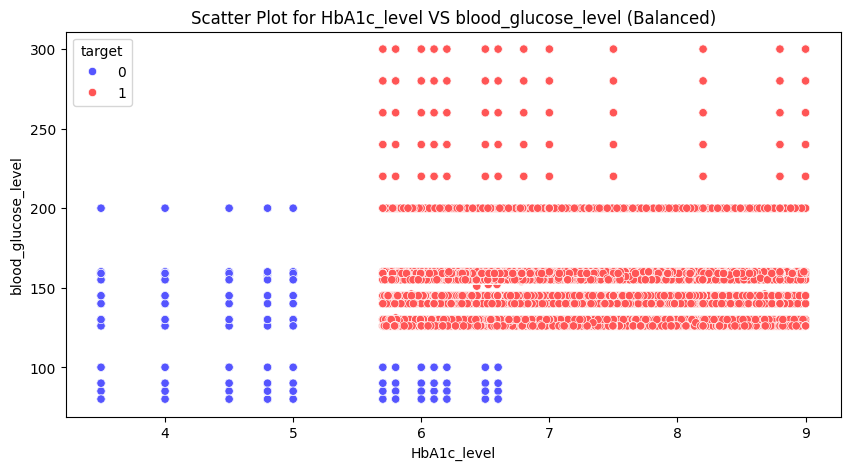

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(
    data=balanced_df,
    x='HbA1c_level',
    y='blood_glucose_level',
    hue='target',
    palette='seismic',
    ax=ax
)
ax.set_title('Scatter Plot for HbA1c_level VS blood_glucose_level (Balanced)')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

#task 2.2 read dataframe

# Разделяем данные на признаки и целевой класс
X = data.drop('diabetes', axis=1)  # Замените 'diabetes' на название целевого столбца
y = data['diabetes']

# Разделяем данные по классам
X_class0 = X[y == 0]  # Данные для класса 0
X_class1 = X[y == 1]  # Данные для класса 1

# 1. Удаление выбросов в классе 0
iso_forest_0 = IsolationForest(random_state=42, contamination=0.05)  # 5% выбросов
outliers_0 = iso_forest_0.fit_predict(X_class0)
X_class0_cleaned = X_class0[outliers_0 == 1]  # Убираем выбросы

# 2. Удаление выбросов в классе 1
iso_forest_1 = IsolationForest(random_state=42, contamination=0.05)  # 5% выбросов
outliers_1 = iso_forest_1.fit_predict(X_class1)
X_class1_cleaned = X_class1[outliers_1 == 1]  # Убираем выбросы

# 3. Урезаем класс 0 до 17,000 объектов
if len(X_class0_cleaned) > 17000:
    X_class0_cleaned, _ = train_test_split(X_class0_cleaned, train_size=17000, random_state=42)

# 4. Объединяем очищенные данные класса 0 и класс 1
X_combined = pd.concat([X_class0_cleaned, X_class1_cleaned])
y_combined = np.concatenate([
    [0] * len(X_class0_cleaned),  # Метки для класса 0
    [1] * len(X_class1_cleaned)  # Метки для класса 1
])

# 5. Применяем SMOTE для избавления от дисбаланса
smote = SMOTE(sampling_strategy=0.97, random_state=42, k_neighbors=5)  # Сбалансировать классы
X_balanced, y_balanced = smote.fit_resample(X_combined, y_combined)

# 6. Проверяем итоговые размеры классов
print("Распределение классов после обработки:")
print(pd.Series(y_balanced).value_counts())

# Финальный результат
balanced_df = pd.concat([pd.DataFrame(X_balanced, columns=X.columns), pd.Series(y_balanced, name='diabetes')], axis=1)

# Просмотр сбалансированных данных
print(balanced_df.head())


In [ ]:
balanced_df

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax = plt.subplots(figsize = (10, 5)) #фигура + координатная плоскость
#Строим диаграмму рассеяния
sns.scatterplot(
    data=balanced_df, #датасет
    x='HbA1c_level', #ось абсцисс
    y='blood_glucose_level', #ось ординат
    hue='diabetes', #группировка
    palette='seismic', #палитра
    ax=ax, #координатная плоскость
);
#Задаём название графика
ax.set_title('Scatter Plot for HbA1c_level VS blood_glucose_level')

In [ ]:
balanced_df

In [ ]:
target_clf = 'diabetes'
features_clf = balanced_df.columns.drop(target_clf)
#data_clf = data_clf.dropna()

X_clf = balanced_df[features_clf]
y_clf = balanced_df[target_clf]

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

In [ ]:
# XGBoost Classifier new
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score
xgb_clf = XGBClassifier(n_estimators=100, use_label_encoder=False, random_state=42)
xgb_clf.fit(X_train_clf, y_train_clf)
xgb_accuracy = accuracy_score(y_test, xgb_clf.predict(X_test))
xgb_baccuracy = balanced_accuracy_score(y_test, xgb_clf.predict(X_test))
xgb_precision = precision_score(y_test, xgb_clf.predict(X_test), average='binary')  # Для бинарной классификации
xgb_recall = recall_score(y_test, xgb_clf.predict(X_test), average='binary')
xgb_f1 = f1_score(y_test, xgb_clf.predict(X_test), average='binary')

print(f"XGBoost Classifier Accuracy: {xgb_accuracy}")
print(f"XGBoost Classifier Balanced Accuracy: {xgb_baccuracy}")
print(f"XGBoost Classifier Precision: {xgb_precision}")
print(f"XGBoost Classifier Recall: {xgb_recall}")
print(f"XGBoost Classifier F1-Score: {xgb_f1}")

print(classification_report(y_test,xgb_clf.predict(X_test)))

In [ ]:
# newest
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

cm = metrics.confusion_matrix(y_test, xgb_clf.predict(X_test))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No diabetes', 'With diabetes'],
            yticklabels=['No diabetes', 'With diabetes'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(metrics.classification_report(y_test, xgb_clf.predict(X_test)))